In [1]:
# %matplotlib ipympl
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PolyCollection
from raytracer_2d import get_verts_2d_from_cuboids
import os

In [2]:
geom_data = np.load("detector_cuboids.npz")
plate_geoms = geom_data["plate cuboids"]
xtal_geoms = geom_data["crystal cuboids"]
xtal_geoms_verts_2d = get_verts_2d_from_cuboids(xtal_geoms)
plate_geoms_verts_2d = get_verts_2d_from_cuboids(plate_geoms)

hulls = np.load("hulls.npy")
intersection_indices = pd.read_csv("intersection_indices.csv")
inclusion_indices = pd.read_csv("inclusion_indices.csv")

In [30]:
insid_indices = []
inter_indices = []
for i in range(864):
    insid_indices.append(inclusion_indices.iloc[i].dropna().values.astype(int))
    inter_indices.append(intersection_indices.iloc[i].dropna().values.astype(int))
    # torch.sort(
    #     torch.cat(
    #         [
    #             torch.tensor(intersection_indices.iloc[i].dropna().values.astype(int)),
    #             torch.tensor(inclusion_indices.iloc[i].dropna().values.astype(int)),
    #         ]
    #     )
    # )[0]


torch.Size([936, 4, 2])


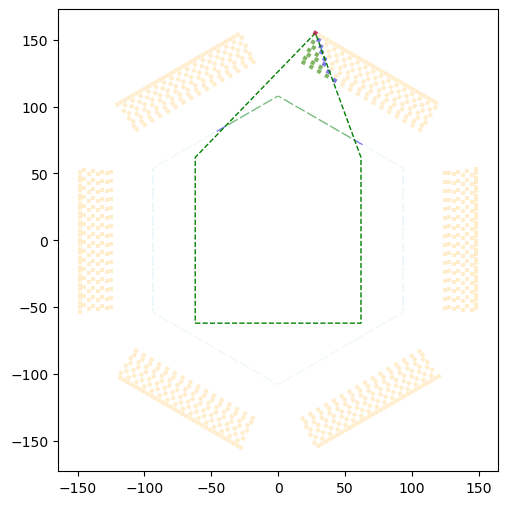

In [31]:
try:
    plt.close()
except Exception as e:
    pass

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.set_aspect("equal")
xtal_rects_pcoll = PolyCollection(
    xtal_geoms_verts_2d.tolist(), ec="none", fc="orange", alpha=0.2
)
plate_rects_pcoll = PolyCollection(
    plate_geoms_verts_2d.tolist(), ec="none", fc="lightblue", alpha=0.2
)
ax.add_collection(plate_rects_pcoll)
all_geoms_verts_2d = torch.vstack([plate_geoms_verts_2d, xtal_geoms_verts_2d])
ax.add_collection(xtal_rects_pcoll)
print(all_geoms_verts_2d.shape)
rects_inter = all_geoms_verts_2d[1:6]
rects_insid = all_geoms_verts_2d[:1]
rects_inter_pcoll = PolyCollection(
    rects_inter.tolist(), fc="blue", alpha=0.5, visible=False
)
rects_insid_pcoll = PolyCollection(
    rects_insid.tolist(), fc="green", alpha=0.5, visible=False
)
ax.add_collection(rects_inter_pcoll)
ax.add_collection(rects_insid_pcoll)
hull_poly = Polygon(
    hulls[0],
    closed=True,
    fill=None,
    edgecolor="green",
    linestyle="--",
    linewidth=1,
)
focused_rects_polygon = Polygon(
    xtal_geoms_verts_2d[0], closed=True, fc="r", ec="none", alpha=0.5
)
ax.add_patch(hull_poly)
ax.add_patch(focused_rects_polygon)
ax.autoscale()
os.makedirs("outputs/images/hulls", exist_ok=True)
for i in torch.arange(xtal_geoms_verts_2d.shape[0]):
    # for i in torch.arange(1):
    hull_verts = hulls[i]
    hull_verts = hull_verts[~(hull_verts[:, 0] == "nan")]
    hull_poly.set_xy(hull_verts)
    rects_insid_pcoll.set_verts(
        all_geoms_verts_2d[
            torch.tensor(insid_indices[i].astype(int))
        ].tolist()
    )
    rects_inter_pcoll.set_verts(
        all_geoms_verts_2d[
            torch.tensor(inter_indices[i].astype(int))
        ].tolist()
    )
    rects_insid_pcoll.set_visible(True)
    rects_inter_pcoll.set_visible(True)
    focused_rects_polygon.set_xy(xtal_geoms_verts_2d[i])
    fig.savefig(f"outputs/images/hulls/xtal_{i}.png")

torch.Size([936, 4, 2])


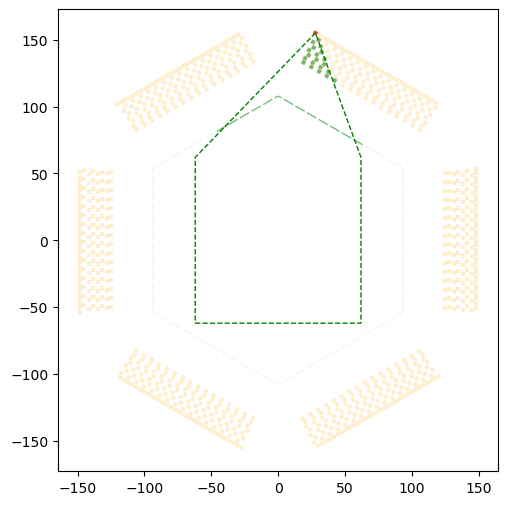

In [32]:
combined_indices = pd.read_csv("combined_indices.csv")
cmb_indices = []
for i in range(864):
    cmb_indices.append(combined_indices.iloc[i].dropna().values.astype(int))

try:
    plt.close()
except Exception as e:
    pass

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.set_aspect("equal")
xtal_rects_pcoll = PolyCollection(
    xtal_geoms_verts_2d.tolist(), ec="none", fc="orange", alpha=0.2
)
plate_rects_pcoll = PolyCollection(
    plate_geoms_verts_2d.tolist(), ec="none", fc="lightblue", alpha=0.2
)
ax.add_collection(plate_rects_pcoll)
all_geoms_verts_2d = torch.vstack([plate_geoms_verts_2d, xtal_geoms_verts_2d])
ax.add_collection(xtal_rects_pcoll)
print(all_geoms_verts_2d.shape)
rects_inter = all_geoms_verts_2d[1:6]
rects_insid = all_geoms_verts_2d[:1]
# rects_inter_pcoll = PolyCollection(
#     rects_inter.tolist(), fc="blue", alpha=0.5, visible=False
# )
rects_insid_pcoll = PolyCollection(
    rects_insid.tolist(), fc="blue", alpha=0.5, visible=False
)
ax.add_collection(rects_inter_pcoll)
ax.add_collection(rects_insid_pcoll)
hull_poly = Polygon(
    hulls[0],
    closed=True,
    fill=None,
    edgecolor="green",
    linestyle="--",
    linewidth=1,
)
focused_rects_polygon = Polygon(
    xtal_geoms_verts_2d[0], closed=True, fc="r", ec="none", alpha=0.5
)
ax.add_patch(hull_poly)
ax.add_patch(focused_rects_polygon)
ax.autoscale()
os.makedirs("outputs/images/hulls_combined", exist_ok=True)
for i in torch.arange(xtal_geoms_verts_2d.shape[0]):
    # for i in torch.arange(1):
    hull_verts = hulls[i]
    hull_verts = hull_verts[~(hull_verts[:, 0] == "nan")]
    hull_poly.set_xy(hull_verts)
    rects_insid_pcoll.set_verts(
        all_geoms_verts_2d[torch.tensor(cmb_indices[i].astype(int))].tolist()
    )
    # rects_inter_pcoll.set_verts(
    #     all_geoms_verts_2d[
    #         torch.tensor(inter_indices[i].astype(int))
    #     ].tolist()
    # )
    rects_insid_pcoll.set_visible(True)
    # rects_inter_pcoll.set_visible(True)
    focused_rects_polygon.set_xy(xtal_geoms_verts_2d[i])
    fig.savefig(f"outputs/images/hulls_combined/xtal_{i}.png")

In [35]:
print(cmb_indices[0])

[ 0  1  2  3  4  5  6 22 23 72]
